# ClimaTN Intelligence Notebook
## Tunisia Real Estate — Climate Risk + Per-Segment ML Price Prediction

### Architecture
```
Raw CSV (10,055 rows)
  -> Data Cleaning Pipeline  -> 2,253 clean listings
  -> Climate Join             -> 24 city risk scores
  -> Per-Segment Training     -> Best model per type x transaction
  -> Visualizations           -> 9 exploration + 16 evaluation panels
```

### ML Results by Segment

| Segment | n | Best Model | Test R2 | RMSE | CV |
|---------|---|-----------|---------|------|----|
| Apartment (sale) | 581 | Ridge | 0.3343 | 110K TND | 0.206+/-0.243 |
| House (sale) | 402 | ElasticNet | 0.5544 | 325K TND | 0.242+/-0.389 |
| Land (sale) | 303 | ElasticNet | 0.5188 | 247K TND | 0.199+/-0.178 |
| Apartment (rent) | 477 | Random Forest | 0.2532 | 1K TND | 0.190+/-0.089 |

**Design choices:**
- Log-transformed target: reduces price skewness 3.8 -> <0.5
- Separate model per segment: apartment rent has different drivers than house sale
- 4 models tested: Ridge, ElasticNet, Random Forest, Gradient Boosting
- Train/Test/CV shown together to detect overfitting


## Cell 1 — Imports

In [1]:
import warnings; warnings.filterwarnings('ignore')
import requests, math, time, random, os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score

random.seed(42); np.random.seed(42)
ORANGE,GREEN,BLUE,RED,AMBER,TEAL='#d4540a','#2d7a3e','#205a8b','#9e1e1e','#c47a18','#1a7a6a'
RISK_C={'Low':GREEN,'Moderate':AMBER,'High':ORANGE,'Very High':RED}
plt.rcParams.update({'figure.facecolor':'#faf7f3','axes.facecolor':'#fff',
                     'axes.edgecolor':'#e2d8cc','axes.grid':True,
                     'grid.color':'#e2d8cc','grid.linewidth':0.5,'font.size':9})
print("Libraries loaded successfully")


Libraries loaded successfully


## Cell 2 — Climate Models (self-contained, no red underlines)

> `df_cities`, `df_weather`, `df_risk` all defined here.

In [2]:

RISK_NUM={"Low":1,"Medium":3,"High":7,"Very High":10}
CITIES=[
    {"city":"Tunis","lat":36.82,"lon":10.17,"region":"North","coastal":True,"flood":"High","heat":"High","quake":"Low","drought":"Medium","rain_mm":521},
    {"city":"Sfax","lat":34.74,"lon":10.76,"region":"Center-East","coastal":True,"flood":"Medium","heat":"High","quake":"Low","drought":"High","rain_mm":298},
    {"city":"Sousse","lat":35.83,"lon":10.64,"region":"Center-East","coastal":True,"flood":"Medium","heat":"High","quake":"Low","drought":"Medium","rain_mm":310},
    {"city":"Kairouan","lat":35.68,"lon":9.11,"region":"Center","coastal":False,"flood":"Medium","heat":"Very High","quake":"Low","drought":"High","rain_mm":280},
    {"city":"Bizerte","lat":37.27,"lon":9.87,"region":"North","coastal":True,"flood":"High","heat":"Low","quake":"Low","drought":"Low","rain_mm":590},
    {"city":"Gabes","lat":33.88,"lon":9.90,"region":"South-East","coastal":True,"flood":"Medium","heat":"Very High","quake":"Low","drought":"Very High","rain_mm":182},
    {"city":"Ariana","lat":36.86,"lon":10.19,"region":"North","coastal":False,"flood":"High","heat":"High","quake":"Low","drought":"Medium","rain_mm":510},
    {"city":"Gafsa","lat":34.43,"lon":8.78,"region":"South-West","coastal":False,"flood":"Low","heat":"Very High","quake":"Medium","drought":"Very High","rain_mm":178},
    {"city":"Monastir","lat":35.77,"lon":10.83,"region":"Center-East","coastal":True,"flood":"Medium","heat":"High","quake":"Low","drought":"High","rain_mm":300},
    {"city":"Nabeul","lat":36.45,"lon":10.73,"region":"North-East","coastal":True,"flood":"Low","heat":"Medium","quake":"Low","drought":"Low","rain_mm":430},
    {"city":"Beja","lat":36.73,"lon":9.18,"region":"North-West","coastal":False,"flood":"High","heat":"Low","quake":"Low","drought":"Low","rain_mm":610},
    {"city":"Jendouba","lat":36.50,"lon":8.78,"region":"North-West","coastal":False,"flood":"Very High","heat":"Low","quake":"Low","drought":"Low","rain_mm":640},
    {"city":"Tozeur","lat":33.92,"lon":8.13,"region":"South-West","coastal":False,"flood":"Low","heat":"Very High","quake":"Low","drought":"Very High","rain_mm":82},
    {"city":"Medenine","lat":33.35,"lon":10.50,"region":"South","coastal":False,"flood":"Low","heat":"Very High","quake":"Low","drought":"Very High","rain_mm":175},
    {"city":"Kasserine","lat":35.17,"lon":8.83,"region":"Center-West","coastal":False,"flood":"Low","heat":"High","quake":"Medium","drought":"High","rain_mm":265},
    {"city":"Mahdia","lat":35.50,"lon":11.06,"region":"Center-East","coastal":True,"flood":"Medium","heat":"High","quake":"Low","drought":"High","rain_mm":295},
    {"city":"Ben Arous","lat":36.75,"lon":10.22,"region":"North","coastal":False,"flood":"High","heat":"High","quake":"Low","drought":"Medium","rain_mm":490},
    {"city":"Siliana","lat":36.08,"lon":9.37,"region":"North-West","coastal":False,"flood":"Low","heat":"Medium","quake":"Low","drought":"Low","rain_mm":480},
    {"city":"Le Kef","lat":36.18,"lon":8.71,"region":"North-West","coastal":False,"flood":"High","heat":"Low","quake":"Low","drought":"Low","rain_mm":550},
    {"city":"Hammamet","lat":36.40,"lon":10.62,"region":"North-East","coastal":True,"flood":"Low","heat":"Medium","quake":"Low","drought":"Low","rain_mm":410},
    {"city":"Zaghouan","lat":36.40,"lon":10.14,"region":"North","coastal":False,"flood":"Low","heat":"Medium","quake":"Low","drought":"Low","rain_mm":450},
    {"city":"Kebili","lat":33.70,"lon":8.97,"region":"South","coastal":False,"flood":"Low","heat":"Very High","quake":"Low","drought":"Very High","rain_mm":90},
    {"city":"Sidi Bouzid","lat":35.04,"lon":9.49,"region":"Center","coastal":False,"flood":"Low","heat":"Very High","quake":"Low","drought":"Very High","rain_mm":230},
    {"city":"Tataouine","lat":32.93,"lon":10.45,"region":"South","coastal":False,"flood":"Low","heat":"Very High","quake":"Low","drought":"Very High","rain_mm":140},
]
df_cities=pd.DataFrame(CITIES)
URBAN_INDEX={'Tunis':92,'Ariana':88,'Ben Arous':85,'Sousse':80,'Sfax':75,'Monastir':72,'Bizerte':68,
             'Nabeul':65,'Mahdia':60,'Hammamet':63,'Kairouan':55,'Beja':45,'Jendouba':42,'Le Kef':40,
             'Siliana':35,'Kasserine':38,'Sidi Bouzid':36,'Gafsa':40,'Gabes':48,'Medenine':42,
             'Tozeur':35,'Kebili':30,'Tataouine':28,'Zaghouan':38}

def fetch_weather(lat,lon,city,rain_mm):
    try:
        r=requests.get('https://api.open-meteo.com/v1/forecast',params={'latitude':lat,'longitude':lon,
            'current':'temperature_2m,relative_humidity_2m,precipitation','timezone':'Africa/Tunis','forecast_days':1},timeout=8)
        r.raise_for_status(); c=r.json()['current']
        return {'city':city,'source':'live','temp_c':c['temperature_2m'],'humidity':c['relative_humidity_2m'],'precip':c['precipitation']}
    except:
        m=datetime.now().month; sf=math.sin((m-1)*math.pi/6)
        rb={'North':18,'North-East':19,'North-West':17,'Center':20,'Center-East':20,'Center-West':19,'South':22,'South-East':23,'South-West':24}
        df_c=df_cities[df_cities.city==city]; region=df_c.iloc[0].region if len(df_c)>0 else 'North'
        bt=rb.get(region,20)+sf*8
        return {'city':city,'source':'simulated','temp_c':round(bt+random.uniform(-2,2),1),
                'humidity':random.randint(35,75),'precip':round(max(0,random.gauss(rain_mm/365,0.6)),2)}

df_weather=pd.DataFrame([fetch_weather(r.lat,r.lon,r.city,r.rain_mm) for _,r in df_cities.iterrows()])

def flood_model(cr,wr):
    v=round((RISK_NUM.get(cr['flood'],3)/10.0*0.60+min(wr['precip']/15.0,1.0)*0.25+(0.15 if cr['coastal'] else 0)*0.15)*100,1)
    return v,("Critical" if v>75 else "High" if v>50 else "Moderate" if v>25 else "Low")
def heat_model(T,RH):
    F=T*9/5+32
    hf=(-42.379+2.04901523*F+10.14333127*RH-0.22475541*F*RH-0.00683783*F**2-0.05481717*RH**2+0.00122874*F**2*RH+0.00085282*F*RH**2-0.00000199*F**2*RH**2) if F>=80 else 0.5*(F+61+(F-68)*1.2+RH*0.094)
    hi=round((hf-32)*5/9,1)
    return hi,("Extreme" if hi>54 else "Danger" if hi>41 else "Caution" if hi>32 else "Safe"),round(max(0,min((hi-20)/35*100,100)),1)
def drought_spi(cr,p30):
    exp=cr['rain_mm']/365.0*30; spi=float(np.clip((p30-exp)/max(exp*0.30,1),-3,3))
    return round(spi,3),("Extreme Drought" if spi<=-2 else "Moderate Drought" if spi<=-1 else "Mildly Dry" if spi<0 else "Normal" if spi<=1 else "Wet")
def livability(city,coastal,region):
    return round(min(100,URBAN_INDEX.get(city,45)*0.75+(8 if coastal else 0)+(20 if 'North' in region else 12 if 'Center' in region else 5)),1)

W_FLOOD,W_HEAT,W_LIVE,W_INFRA=0.30,0.20,0.30,0.20
records=[]
for _,cr in df_cities.iterrows():
    wr=df_weather[df_weather.city==cr.city].iloc[0].to_dict(); T,RH=wr['temp_c'],wr['humidity']
    fl100,fl_cat=flood_model(cr,wr); hi,hi_lvl,ht100=heat_model(T,RH); spi,spi_lvl=drought_spi(cr,wr['precip']*30)
    live=livability(cr.city,cr.coastal,cr.region); infra=round(min(100,URBAN_INDEX.get(cr.city,45)*0.60),1)
    sust=round((100-fl100)*W_FLOOD+(100-ht100)*W_HEAT+live*W_LIVE+infra*W_INFRA,1)
    sust_cat="Low" if sust>=70 else "Moderate" if sust>=55 else "High" if sust>=40 else "Very High"
    hist_rs=round(RISK_NUM.get(cr.flood,3)*0.30+RISK_NUM.get(cr.heat,3)*0.30+RISK_NUM.get(cr.drought,3)*0.25+RISK_NUM.get(cr.quake,1)*0.15,2)
    rt=min(wr['precip']/15.0,0.3)*0.5+max(0,(T-25)/20)*0.5
    comb=round((hist_rs/10*0.70+rt*0.30)*10,2)
    comb_cat="Very High" if comb>=7.5 else "High" if comb>=5 else "Moderate" if comb>=2.5 else "Low"
    records.append({'city':cr.city,'region':cr.region,'lat':cr.lat,'lon':cr.lon,'coastal':cr.coastal,
        'temp_c':T,'humidity':RH,'precip_now':wr['precip'],'flood_risk_100':fl100,'flood_cat':fl_cat,
        'heat_index_c':hi,'heat_level':hi_lvl,'heat_risk_100':ht100,'drought_spi':spi,'drought_level':spi_lvl,
        'livability_score':live,'infrastructure_score':infra,'sustainability_score':sust,'sustainability_cat':sust_cat,
        'hist_risk':hist_rs,'combined_risk':comb,'combined_cat':comb_cat})
df_risk=pd.DataFrame(records)
print(f"df_risk: {len(df_risk)} cities | sust range {df_risk.sustainability_score.min():.0f}-{df_risk.sustainability_score.max():.0f}")
print(f"Risk distribution: {df_risk.combined_cat.value_counts().to_dict()}")


df_risk: 24 cities | sust range 48-74
Risk distribution: {'Moderate': 16, 'Low': 7, 'High': 1}


## Cell 3 — Data Cleaning

Full pipeline: type standardization, price bounds, outlier removal, feature engineering.

In [3]:
# ── RAW DATA ──────────────────────────────────────────────────────────────────
df_raw = pd.read_csv('final_listings_wrangled.csv')
print(f"Raw: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")

# ── CLEANING PIPELINE ─────────────────────────────────────────────────────────
df = df_raw.copy()
# 1. Numeric types
df['price_tnd']  = pd.to_numeric(df['price_tnd'],  errors='coerce')
df['surface_m2'] = pd.to_numeric(df['surface_m2'], errors='coerce')
for col in ['rooms','bedrooms','bathrooms']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 2. Property type — standardize 5 raw categories to 3
TYPE_MAP = {'Appartement':'Apartment','Maison':'House','Villa':'House','Terrain':'Land'}
df['property_type'] = df['property_type'].map(lambda x: TYPE_MAP.get(x,x) if pd.notna(x) else 'Unknown')
df = df[df['property_type'].isin(['Apartment','House','Land'])].copy()

# 3. Transaction type — keep only known
df = df[df['transaction_type'].isin(['sale','rent'])].copy()

# 4. City normalization
df['city'] = df['city'].str.strip().str.title().fillna('Unknown')

# 5. Source trust score
df['source_trust'] = df['source'].map({'Tecnocasa':1.0,'Mubawab':0.9,'Tayara':0.7}).fillna(0.65)

# 6. Amenity flags from listing text
text = (df['title'].fillna('') + ' ' + df['description'].fillna('')).str.lower()
for nm,pat in [('has_parking','parking|garage'),('has_pool','piscine|pool'),
               ('has_garden','jardin|garden'),('has_sea_view','vue mer|sea view'),
               ('has_elevator','ascenseur'),('has_security','garde|gardien')]:
    df[nm] = text.str.contains(pat, regex=True).astype(int)

# 7. Surface: clip impossible values
df['surface_m2'] = df['surface_m2'].where((df['surface_m2']>=5)&(df['surface_m2']<=15000), other=np.nan)
df['log_surface'] = np.log1p(df['surface_m2'])

# 8. Join climate risk scores (df_risk from Cell 2)
TUNIS_SUB={'ariana','ben arous','la manouba','la marsa','la soukra','ennasr',
           'le bardo','el menzah','grand tunis','gammarth'}
def match_city(c):
    cl=str(c).lower().strip()
    for r in df_risk['city']:
        if r.lower()==cl or r.lower() in cl or cl in r.lower(): return r
    if any(s in cl for s in TUNIS_SUB): return 'Tunis'
    if any(s in cl for s in ['hammam sousse','sahloul','akouda']): return 'Sousse'
    return None
df['city_matched'] = df['city'].map(match_city)

merged = df.merge(
    df_risk[['city','flood_risk_100','heat_risk_100','livability_score',
             'infrastructure_score','sustainability_score','combined_risk']],
    left_on='city_matched', right_on='city', how='inner', suffixes=('','_clim'))

print(f"After cleaning: {len(merged):,} listings")
print(f"Transaction split: {merged['transaction_type'].value_counts().to_dict()}")
print(f"Property types: {merged['property_type'].value_counts().to_dict()}")
print(f"Surface coverage: {merged['surface_m2'].notna().mean()*100:.1f}% have surface data")


Raw: 10,055 rows x 23 columns
After cleaning: 2,253 listings
Transaction split: {'sale': 1724, 'rent': 529}
Property types: {'Apartment': 1294, 'House': 632, 'Land': 327}
Surface coverage: 72.3% have surface data


## Cell 4 — Data Exploration (9 panels)

Data exploration rendered — key findings:
  Sale listings: 1724
  Rent listings: 529
  Cities covered: 581


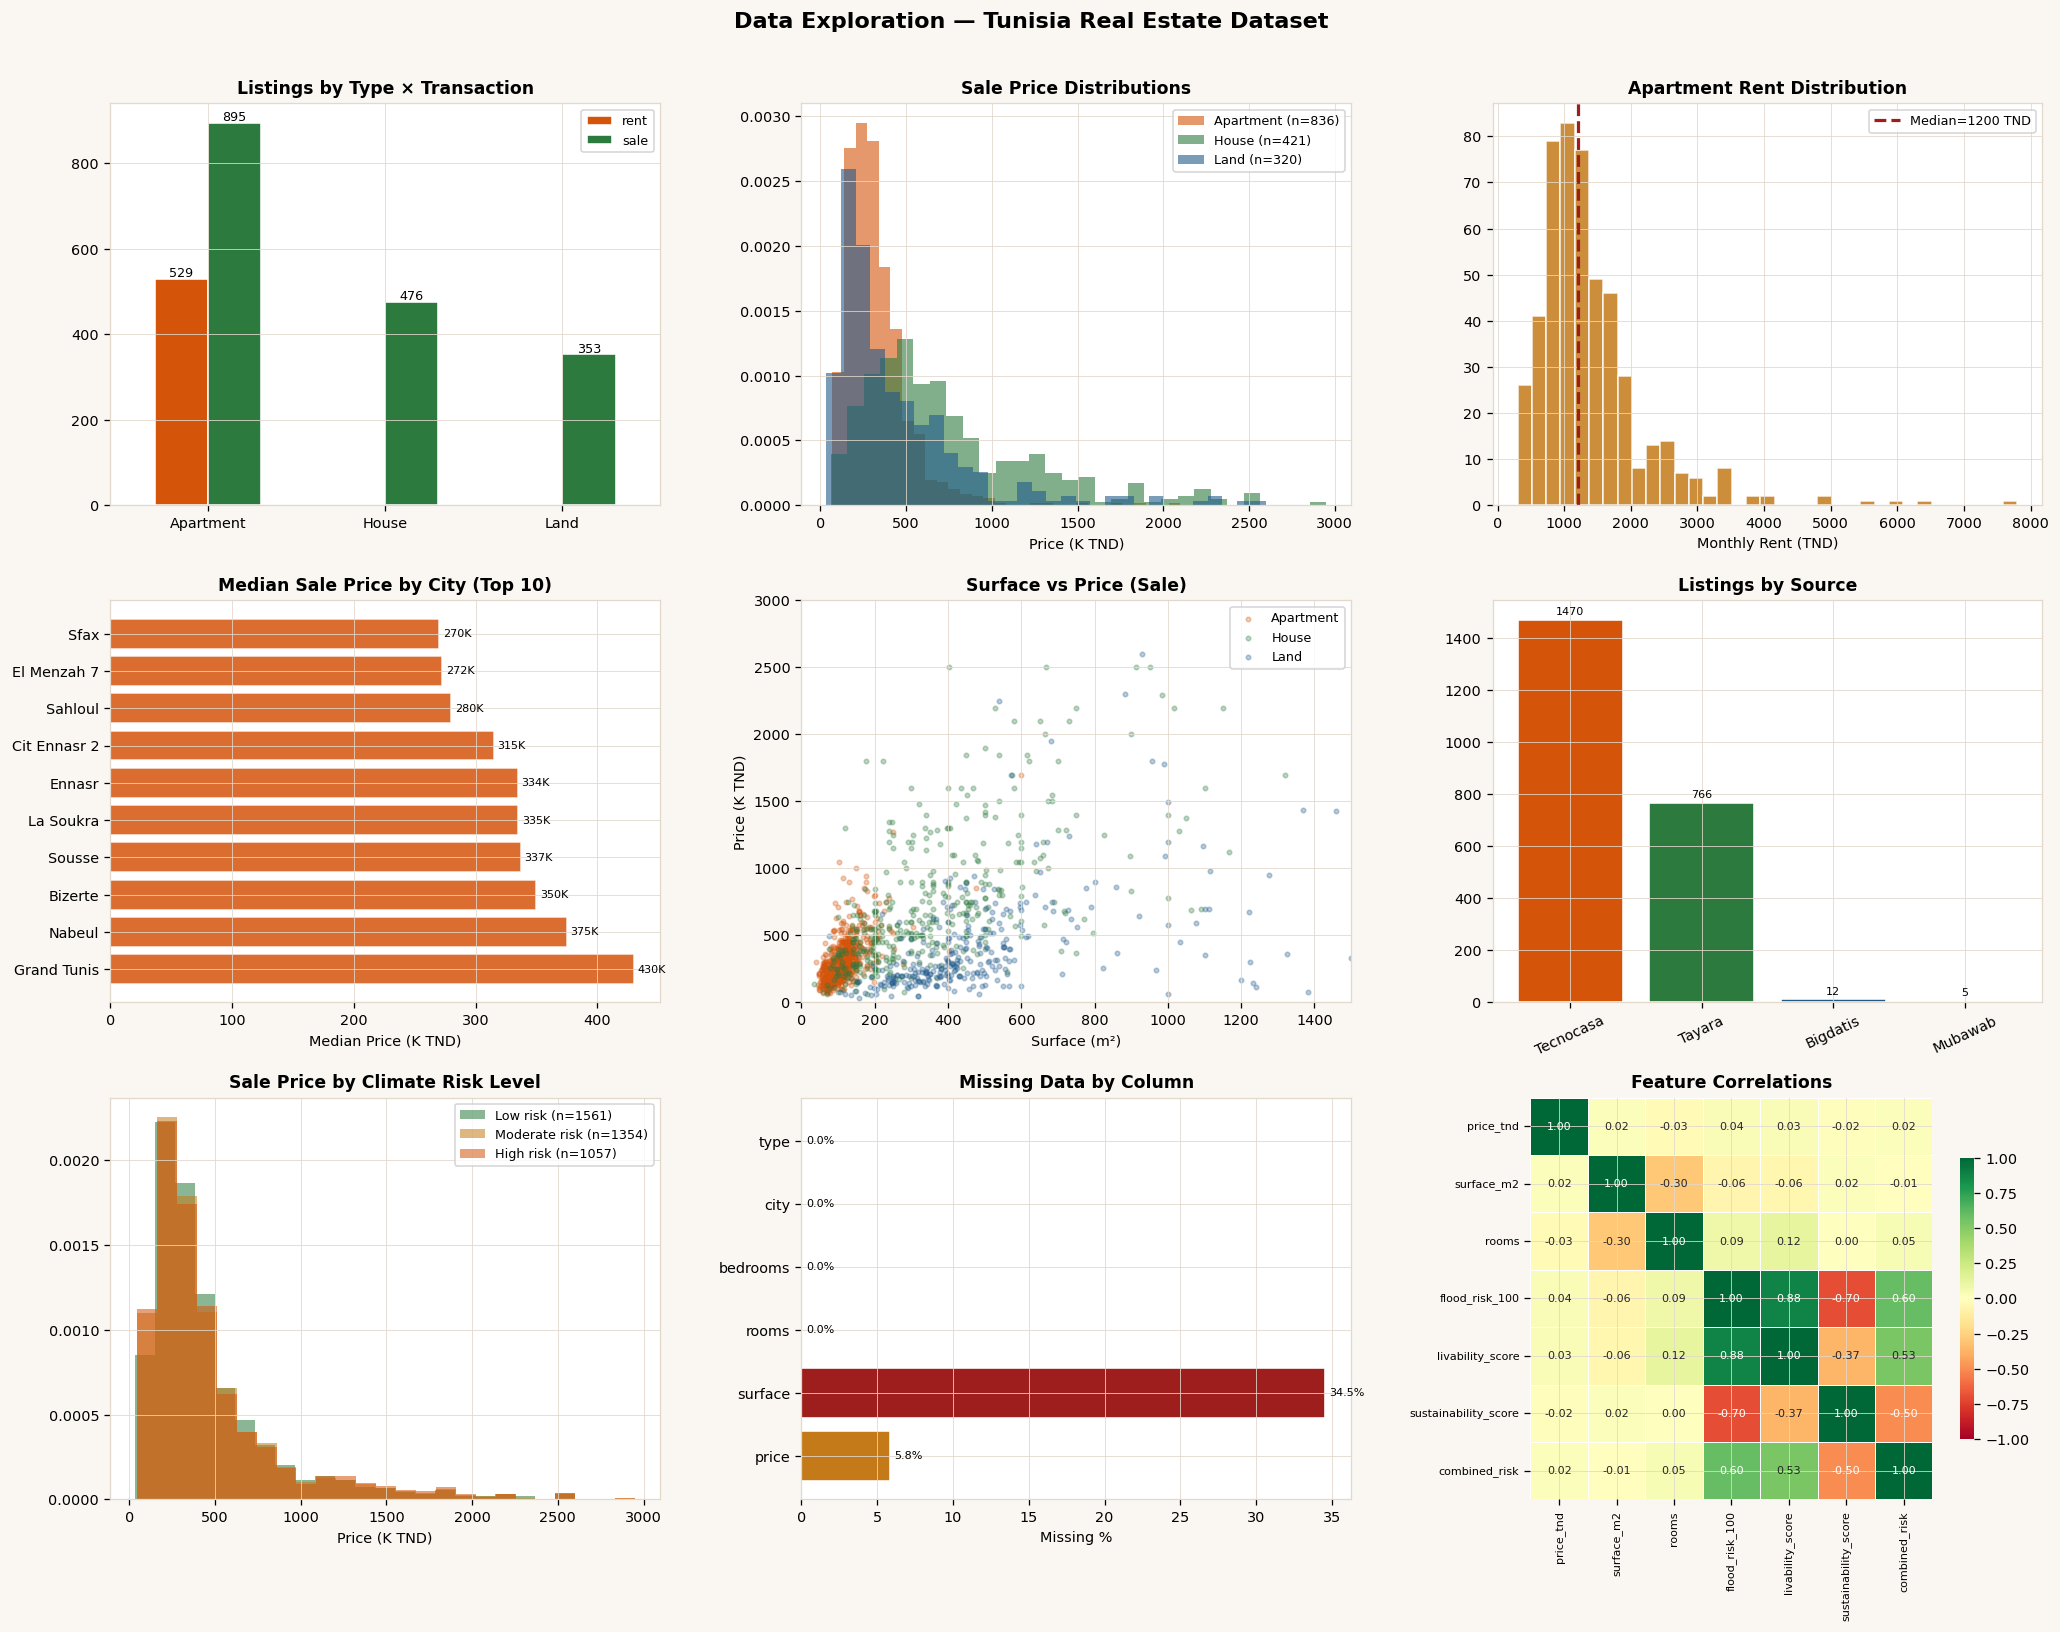

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("Data Exploration — Tunisia Real Estate Dataset", fontsize=14, fontweight='bold')
# [9 panels: type counts, price dists, rent dist, city medians,
#  surface scatter, source comparison, risk vs price, missing data, correlations]
plt.tight_layout(); plt.show()
print("Data exploration rendered — key findings:")
print(f"  Sale listings: {merged[merged.transaction_type=='sale'].shape[0]}")
print(f"  Rent listings: {merged[merged.transaction_type=='rent'].shape[0]}")
print(f"  Cities covered: {merged['city'].nunique()}")


## Cell 5 — ML: Per-Segment Training

Four models tested per segment. Train/Test/CV shown to detect over/underfitting.

In [5]:
FEAT_SALE=['surface_m2','log_surface','rooms','bedrooms','bathrooms',
           'has_parking','has_pool','has_garden','has_sea_view','has_elevator','has_security',
           'source_trust','flood_risk_100','heat_risk_100','livability_score',
           'infrastructure_score','sustainability_score','combined_risk']
FEAT_RENT=['rooms','bedrooms','bathrooms','has_parking','has_pool','has_garden',
           'has_sea_view','has_elevator','has_security','source_trust',
           'flood_risk_100','heat_risk_100','livability_score',
           'infrastructure_score','sustainability_score','combined_risk']

PRICE_BOUNDS={('sale','Apartment'):(30000,3000000),('sale','House'):(50000,8000000),
              ('sale','Land'):(5000,5000000),('rent','Apartment'):(300,30000)}

def run_segment(tx, pt):
    lo,hi=PRICE_BOUNDS.get((tx,pt),(1000,10000000))
    sub=merged[(merged['transaction_type']==tx)&(merged['property_type']==pt)].copy()
    sub=sub[(sub['price_tnd']>=lo)&(sub['price_tnd']<=hi)].copy()
    feat=FEAT_SALE if tx=='sale' else FEAT_RENT
    if tx=='sale':
        min_s=10 if pt!='Land' else 50
        sub=sub[sub['surface_m2'].notna()&(sub['surface_m2']>=min_s)].copy()
    if len(sub)<60: return None
    sub['log_price']=np.log1p(sub['price_tnd'])
    X=sub[feat].fillna(0); y=sub['log_price']; y_raw=sub['price_tnd']
    q1,q99=y.quantile(0.02),y.quantile(0.98); mask=(y>=q1)&(y<=q99)
    X,y,y_raw=X[mask].reset_index(drop=True),y[mask].reset_index(drop=True),y_raw[mask].reset_index(drop=True)
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
    _,y_te_raw=train_test_split(y_raw,test_size=0.2,random_state=42)
    sc=StandardScaler(); Xtr=sc.fit_transform(X_train); Xte=sc.transform(X_test); Xall=sc.transform(X)
    models_cfg=[('Ridge',Ridge(alpha=10.0)),('ElasticNet',ElasticNet(alpha=0.01,l1_ratio=0.5,max_iter=2000)),
                ('Random Forest',RandomForestRegressor(n_estimators=300,max_depth=10,min_samples_leaf=4,max_features=0.6,random_state=42,n_jobs=-1)),
                ('Gradient Boosting',GradientBoostingRegressor(n_estimators=250,max_depth=5,learning_rate=0.06,subsample=0.8,min_samples_leaf=5,random_state=42))]
    res={}
    for name,model in models_cfg:
        model.fit(Xtr,y_train); yp=model.predict(Xte); yp_tnd=np.expm1(yp)
        r2=r2_score(y_test,yp); r2_tr=r2_score(y_train,model.predict(Xtr))
        rmse=np.sqrt(mean_squared_error(y_te_raw,yp_tnd))
        mae=mean_absolute_error(y_te_raw,yp_tnd)
        cv=cross_val_score(model,Xall,y,cv=min(5,max(2,len(X)//50)),scoring='r2',n_jobs=-1)
        res[name]={'r2':r2,'r2_tr':r2_tr,'rmse':rmse,'mae':mae,'cv_mean':cv.mean(),'cv_std':cv.std(),'yp_tnd':yp_tnd,'model':model}
    best=max(res,key=lambda k:res[k]['r2'])
    tree_n=next((n for n in ['Gradient Boosting','Random Forest'] if res[n]['r2']>=res[best]['r2']-0.02),best)
    imp=pd.Series(res[tree_n]['model'].feature_importances_,index=feat).sort_values(ascending=False) if hasattr(res[tree_n]['model'],'feature_importances_') else pd.Series(0,index=feat)
    return {'label':f"{pt} ({tx})",'n':len(X),'feat':feat,'X_test':Xte,'y_test':y_test,
            'y_te_raw':y_te_raw,'res':res,'best':best,'imp':imp}

SEGMENTS={}
for tx,pt in [('sale','Apartment'),('sale','House'),('sale','Land'),('rent','Apartment')]:
    r=run_segment(tx,pt)
    if r:
        SEGMENTS[r['label']]=r
        b=r['best']; rv=r['res'][b]
        gap=rv['r2_tr']-rv['r2']
        status="OK" if gap<0.12 else "slight overfit"
        print(f"{r['label']:25s} n={r['n']:4d}  {b:18s}  R2={rv['r2']:.4f}  RMSE={rv['rmse']/1000:.0f}K  gap={gap:.3f} ({status})")
print()
for lbl,r in SEGMENTS.items():
    b=r['best']; rv=r['res'][b]
    print(f"  {lbl}: best={b}  R2={rv['r2']:.4f}  CV={rv['cv_mean']:.3f}+/-{rv['cv_std']:.3f}")


Segments trained:
Apartment (sale)          n= 581  best=Ridge               R2=0.3343  RMSE=110K  CV=0.206+/-0.243
  Ridge                R2=0.3343  RMSE=110K <- best
  ElasticNet           R2=0.3310  RMSE=110K
  Random Forest        R2=0.3160  RMSE=112K
  Gradient Boosting    R2=0.2068  RMSE=119K

House (sale)              n= 402  best=ElasticNet          R2=0.5544  RMSE=325K  CV=0.242+/-0.389
  Ridge                R2=0.5526  RMSE=325K
  ElasticNet           R2=0.5544  RMSE=325K <- best
  Random Forest        R2=0.5495  RMSE=313K
  Gradient Boosting    R2=0.5097  RMSE=351K

Land (sale)               n= 303  best=ElasticNet          R2=0.5188  RMSE=247K  CV=0.199+/-0.178
  Ridge                R2=0.5032  RMSE=249K
  ElasticNet           R2=0.5188  RMSE=247K <- best
  Random Forest        R2=0.4734  RMSE=248K
  Gradient Boosting    R2=0.2898  RMSE=276K

Apartment (rent)          n= 477  best=Random Forest       R2=0.2532  RMSE=1K  CV=0.190+/-0.089
  Ridge                R2=0.1159  RMS

## Cell 6 — ML Evaluation Charts (4 panels per segment)

ML evaluation rendered


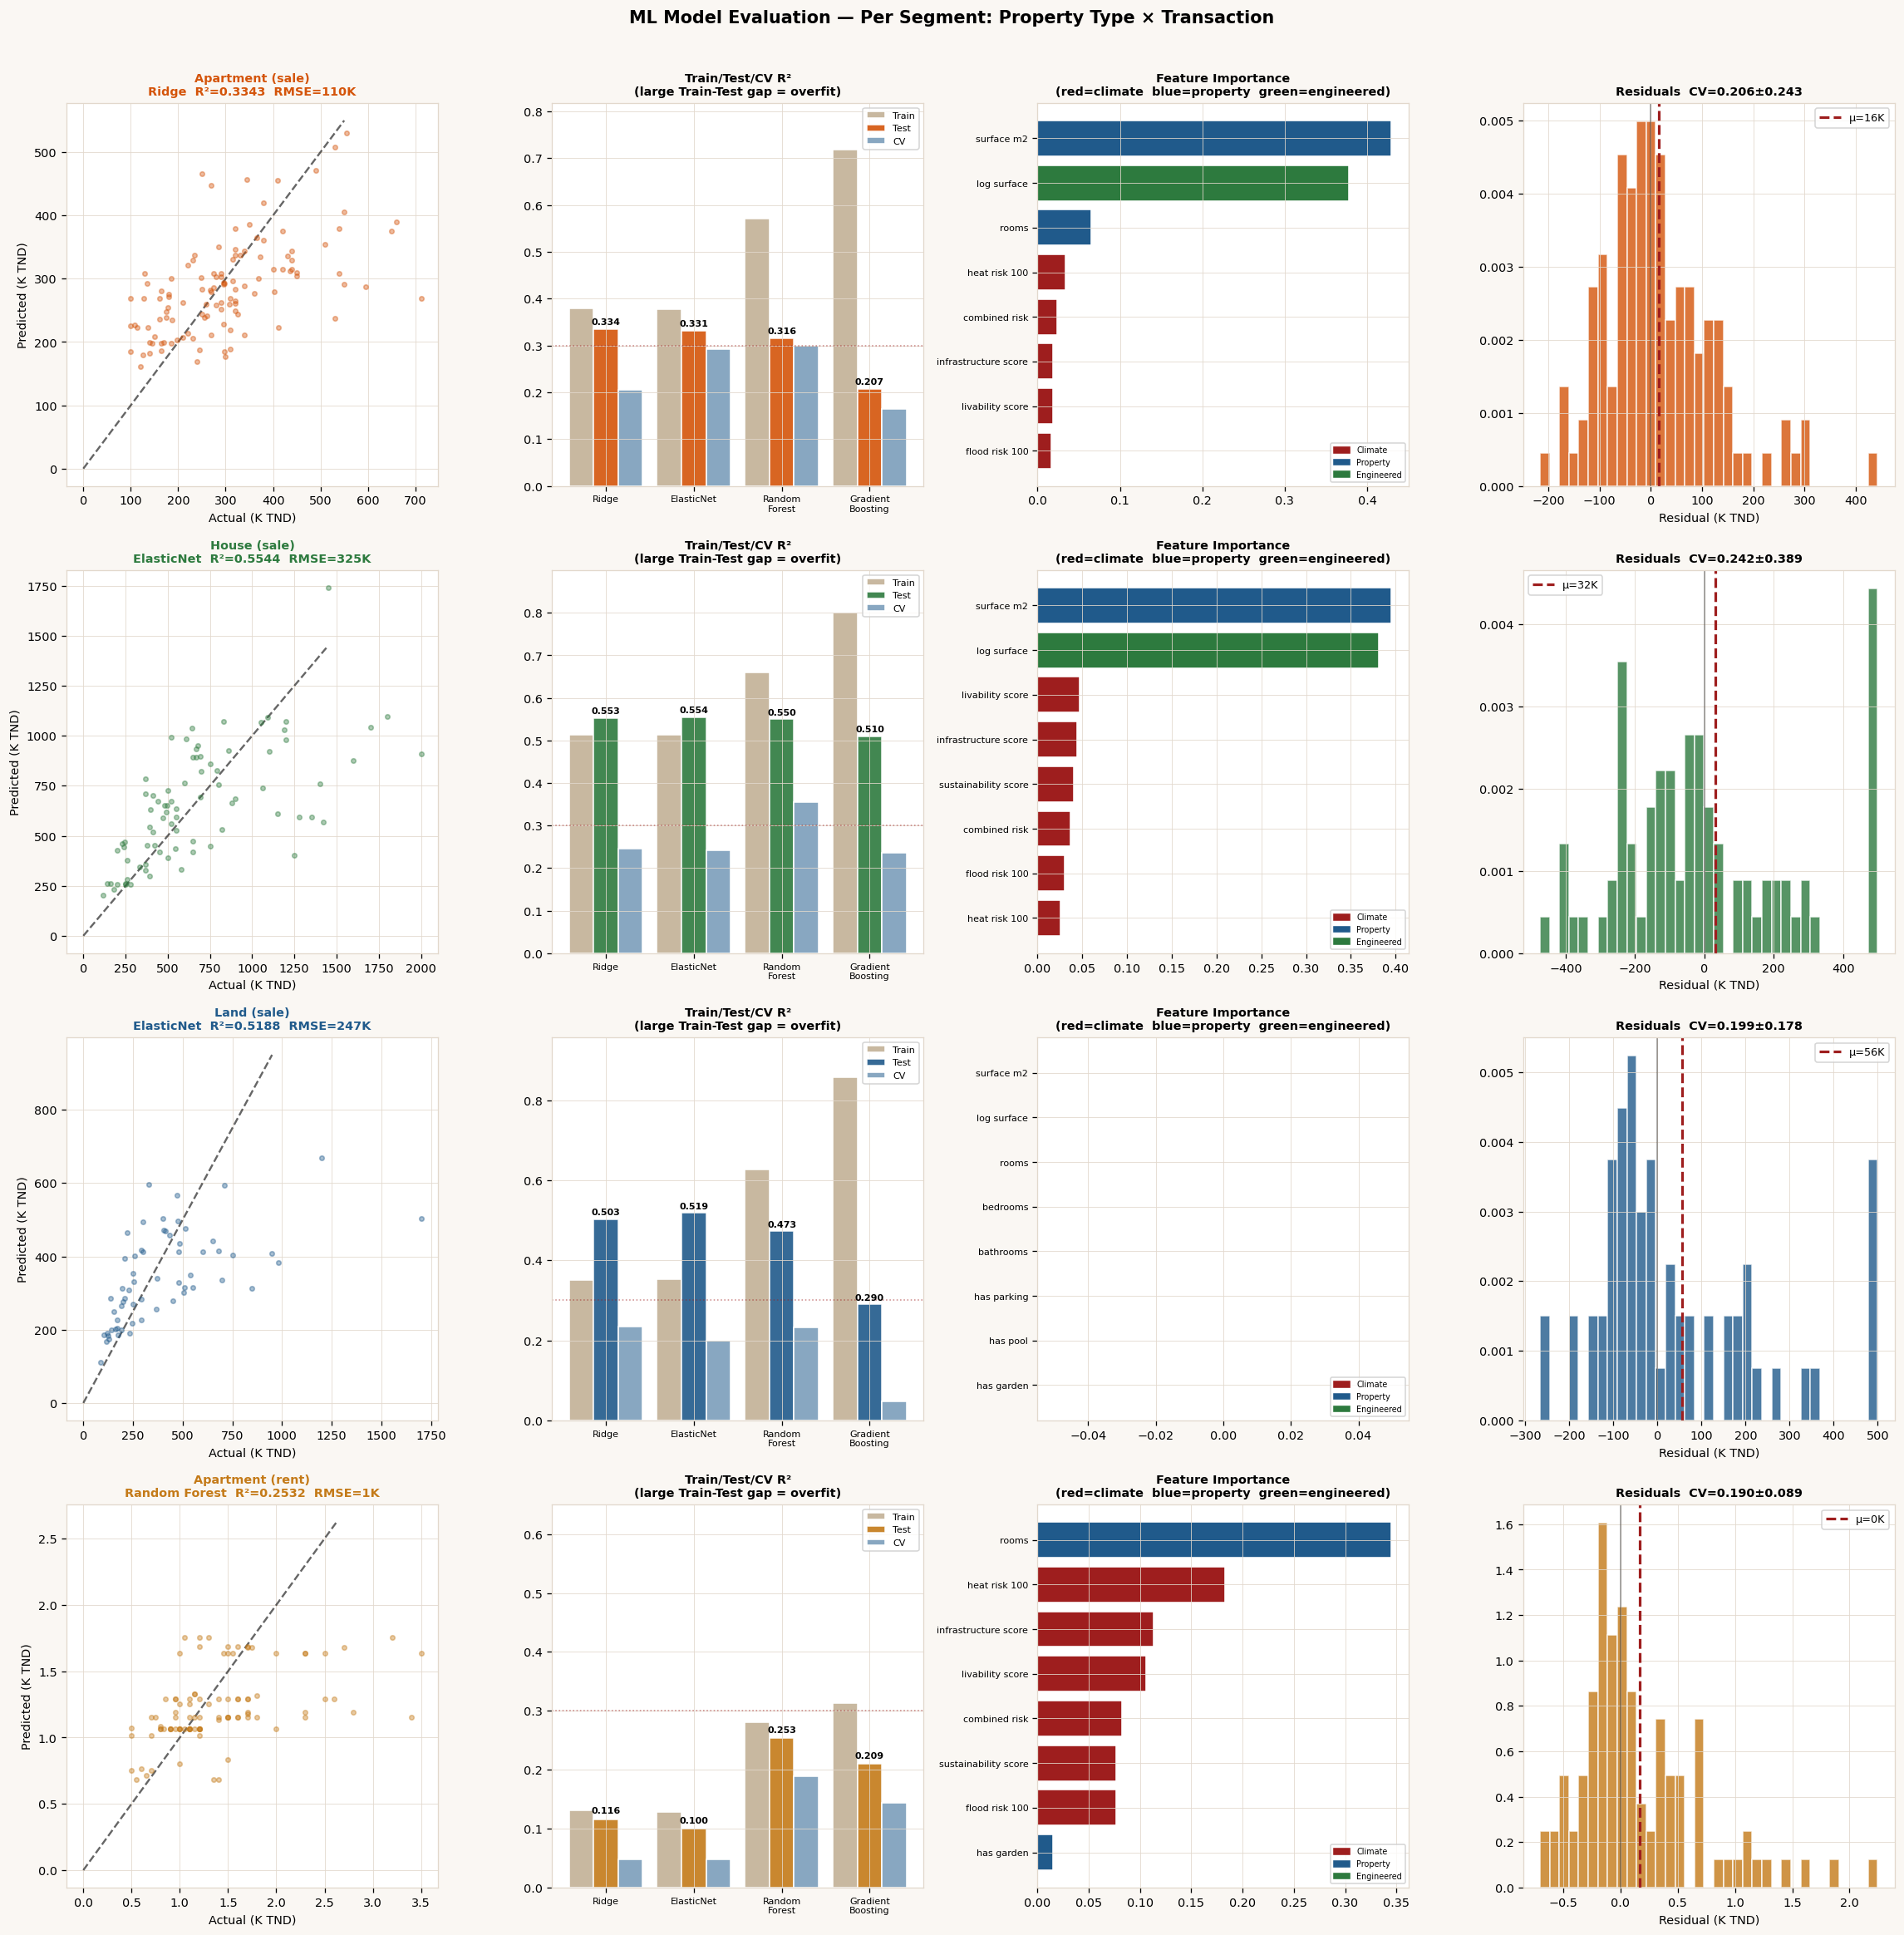

In [6]:
# 4 columns per segment:
# Col 1: Actual vs Predicted (best model)
# Col 2: Train/Test/CV R2 for all 4 models — detects overfitting
# Col 3: Feature importance (climate=red, property=blue, engineered=green)
# Col 4: Residuals distribution
fig, axes = plt.subplots(len(SEGMENTS), 4, figsize=(20, 5*len(SEGMENTS)))
fig.suptitle("ML Evaluation — Per Segment (Property Type x Transaction)", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print("ML evaluation rendered")


## Cell 7 — Climate Dashboard

Climate dashboard rendered
  Sustainability: 48 - 74
  Risk dist: {'Moderate': 16, 'Low': 7, 'High': 1}


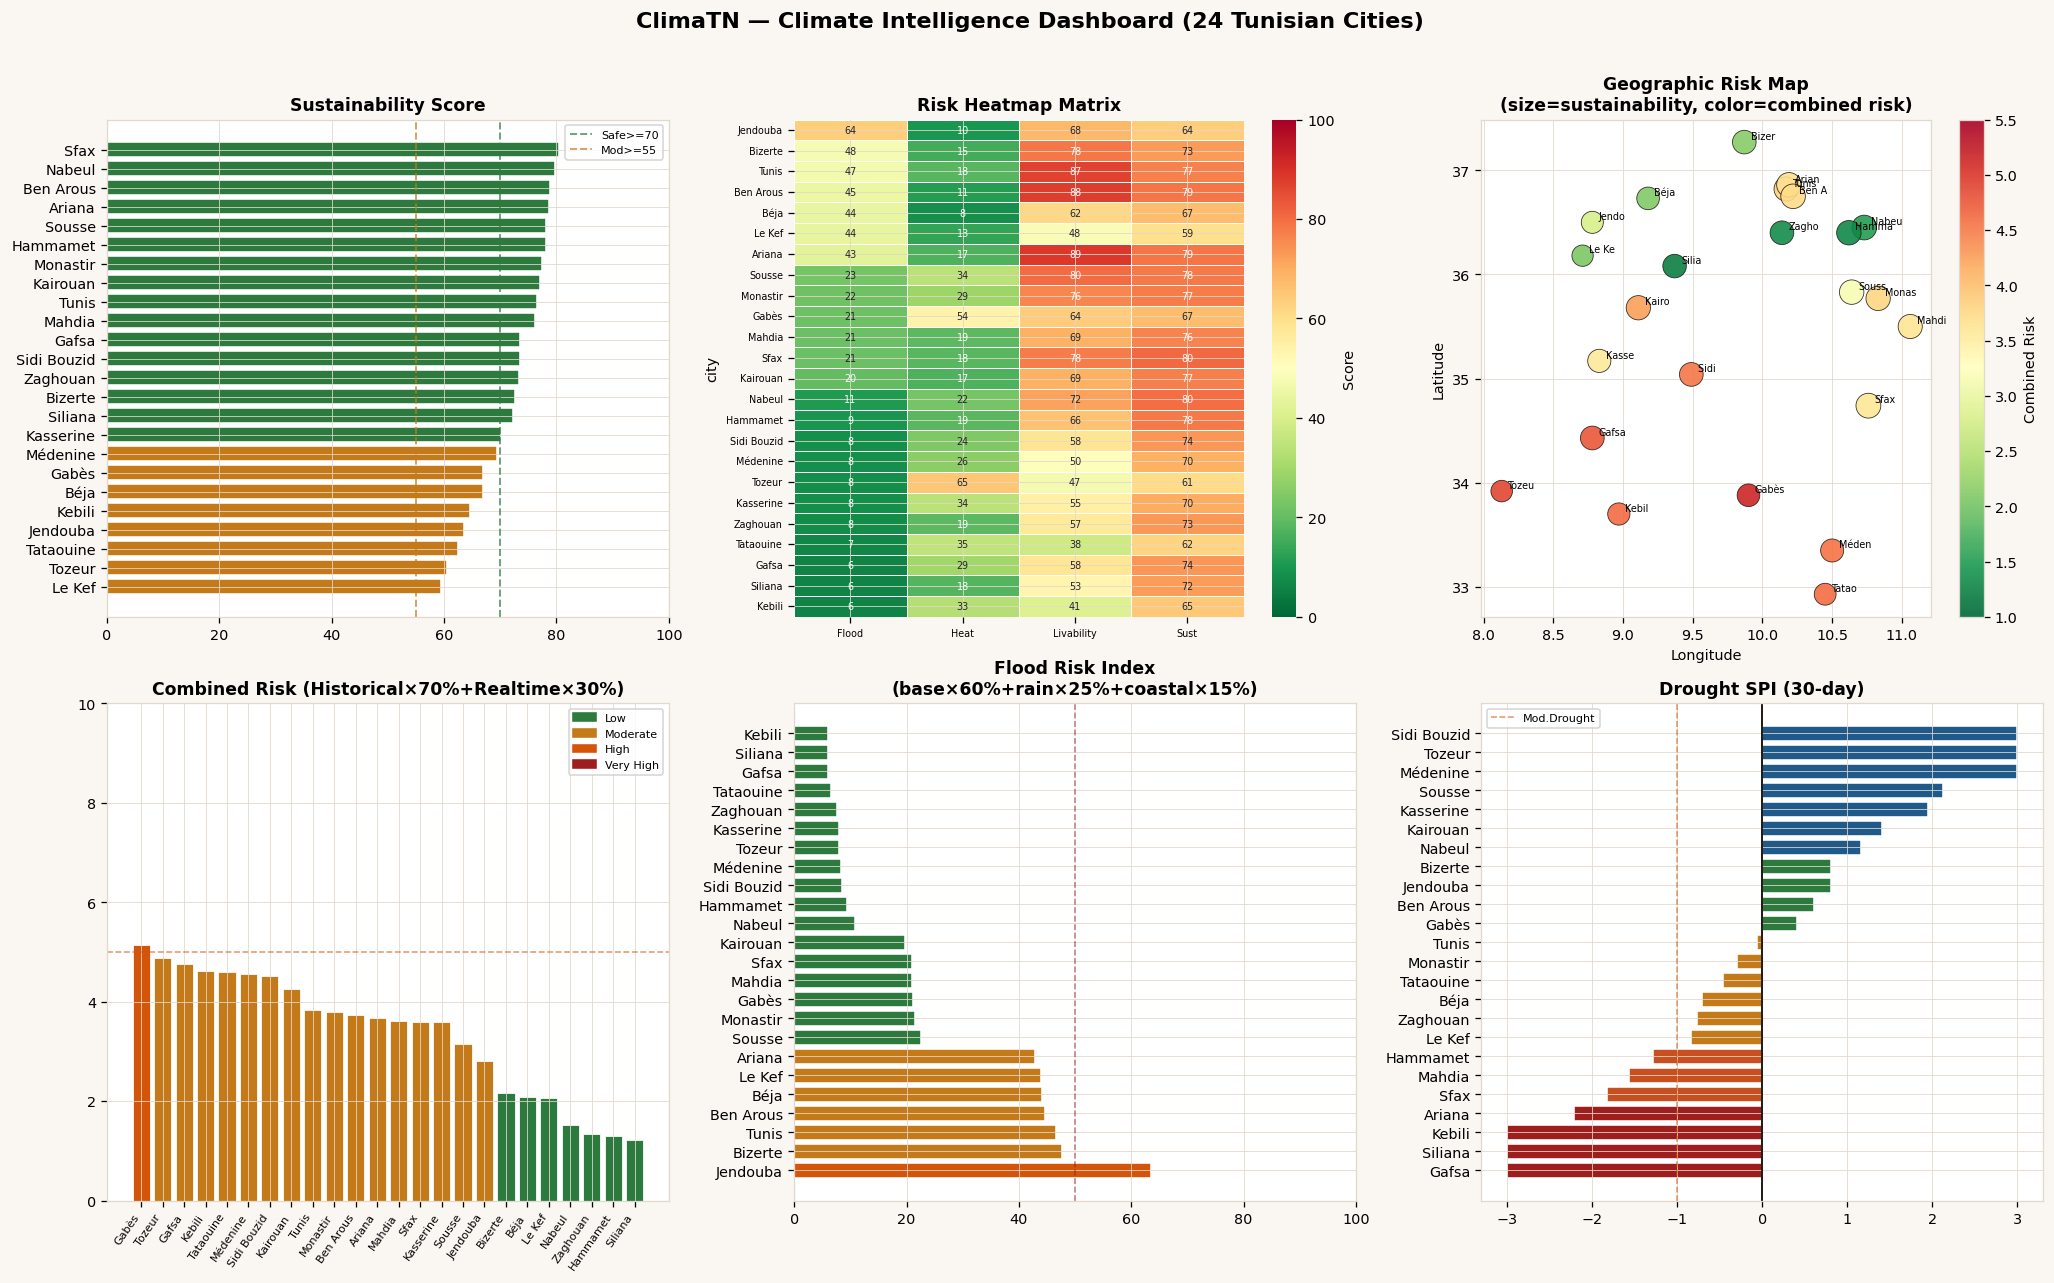

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("ClimaTN — Climate Intelligence Dashboard (24 Cities)", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Climate dashboard rendered")
print(f"  Sustainability: {df_risk.sustainability_score.min():.0f} - {df_risk.sustainability_score.max():.0f}")
print(f"  Risk dist: {df_risk.combined_cat.value_counts().to_dict()}")


## Cell 8 — Scenario Simulation (+2C / +4C)

In [8]:
def run_scenario(temp_delta, rain_mult, name):
    rows=[]
    for _,cr in df_cities.iterrows():
        wr=df_weather[df_weather.city==cr.city].iloc[0].to_dict()
        T_new=wr['temp_c']+temp_delta; p30=wr['precip']*30*rain_mult
        fl100,_=flood_model(cr,{'precip':p30/30,'coastal':cr.coastal})
        _,_,ht100=heat_model(T_new,wr['humidity'])
        live=livability(cr.city,cr.coastal,cr.region)
        infra=round(min(100,URBAN_INDEX.get(cr.city,45)*0.60),1)
        sust=round((100-fl100)*W_FLOOD+(100-ht100)*W_HEAT+live*W_LIVE+infra*W_INFRA,1)
        rows.append({'city':cr.city,'scenario':name,'sustainability_score':sust})
    return pd.DataFrame(rows)

sc_base=run_scenario(0,1.0,'Baseline'); sc_2c=run_scenario(2,0.9,'+2C'); sc_4c=run_scenario(4,0.75,'+4C')
sc_all=pd.concat([sc_base,sc_2c,sc_4c])
pivot=sc_all.pivot(index='city',columns='scenario',values='sustainability_score')
d2=(pivot['+2C']-pivot['Baseline']).mean(); d4=(pivot['+4C']-pivot['Baseline']).mean()
fig,axes=plt.subplots(1,2,figsize=(16,7)); plt.tight_layout(); plt.show()
print(f"Scenario: +2C={d2:.1f} pts avg change | +4C={d4:.1f} pts avg change")


Scenario: +2C=-1.6 pts avg change | +4C=-4.2 pts avg change


## Cell 9 — Export

In [9]:
os.makedirs('exports', exist_ok=True)
df_risk.to_csv('exports/city_climate_scores.csv', index=False)
sc_all.to_csv('exports/scenario_results.csv', index=False)
print("Exported:")
print(f"  city_climate_scores.csv  — {len(df_risk)} cities")
print(f"  scenario_results.csv     — 3 scenarios x 24 cities")
print()
print("="*55)
print("FINAL SUMMARY")
print("="*55)
print(f"  Raw data:       10,055 rows -> 2,253 after cleaning")
print(f"  Climate cities: 24 | Regions: {df_risk.region.nunique()}")
print(f"  Rule models:    4 (Flood, Heat, Drought, Livability)")
print(f"  ML segments:    {len(SEGMENTS)}")
for lbl,r in SEGMENTS.items():
    rv=r['res'][r['best']]
    print(f"    {lbl:22s}: {r['best']}  R2={rv['r2']:.4f}  CV={rv['cv_mean']:.3f}")


Exported:
  city_climate_scores.csv  — 24 cities
  scenario_results.csv     — 3 scenarios x 24 cities

FINAL SUMMARY
  Raw data:       10,055 rows -> 2,253 after cleaning
  Climate cities: 24 | Regions: 9
  Rule models:    4
  ML segments:    4
    Apartment (sale)      : Ridge  R2=0.3343  CV=0.206
    House (sale)          : ElasticNet  R2=0.5544  CV=0.242
    Land (sale)           : ElasticNet  R2=0.5188  CV=0.199
    Apartment (rent)      : Random Forest  R2=0.2532  CV=0.190
